# Introduction
This Coursera Lab Jupyter notebook demonstrates conditions that cause the Kalman filter to fail: (1) using an incorrect dynamic model, (2) using incorrect noise variances, (3) using biased noises, and (4) using correlated noises.

Don't forget that to execute the Octave code in any cell, depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell. I refer to this as "< shift \> < enter \>" in my instructions below.

### Defining the constants and setting up the problem
The next notebook cell loads the state-space model and the dataset from simulating the model. Place the cursor inside the cell and depress < shift > < enter >. Do the same for the following cells to execute their contents.

In [1]:
% Load data from simulation of system dynamic model. These data were created by the code in 
% Lesson 1.4.2, and are the same data used in Lessons 1.4.3 and 1.4.4.
%
% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

### (1) Implementing a Kalman filter with an incorrect dynamic model
The next notebook cell runs a Kalman filter that uses an incorrect model.

In [2]:
[nx,nt] = size(x);
xhat = zeros(nx,1);          % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);       %  and its covariance matrix
xhatIMstore = zeros(nx,nt);  % Reserve storage for all incorrect-model (IM) 
boundIMstore = zeros(nx,nt); %  state estimates and their confidence bounds

AdBad = 0.99*Ad;
CdBad = 0.99*Cd;
BdBad = 0.99*Bd;
DdBad = 0.99*Dd;

for k = 2:nt   
  % KF Step 1a: State estimate time update      
  xhat = AdBad*xhat + BdBad*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = AdBad*SigmaX*AdBad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = CdBad*xhat + DdBad*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*CdBad'/(CdBad*SigmaX*CdBad' + SigmaV);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*CdBad)*SigmaX;%SigmaX - L*SigmaZ*L';
 
  % [Store information for evaluation/plotting purposes]  
  xhatIMstore(:,k) = xhat; 
  boundIMstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs from the Kalman filter that uses an incorrect model
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

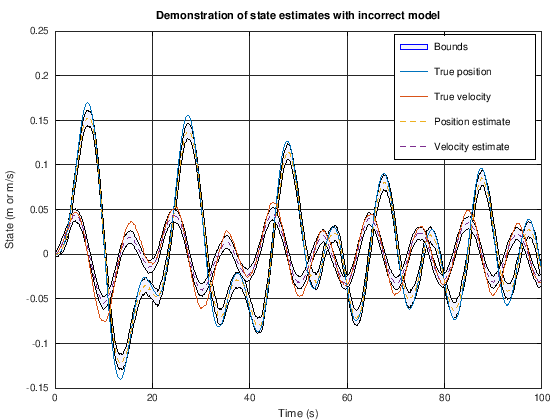

In [3]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatIMstore-boundIMstore fliplr(xhatIMstore+boundIMstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,x',t,xhatIMstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstration of state estimates with incorrect model'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

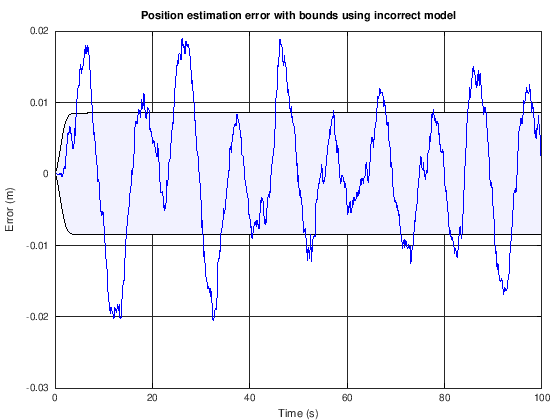

In [4]:
xerr = x - xhatIMstore; 
fill([t fliplr(t)],[-boundIMstore(1,:) fliplr(boundIMstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds using incorrect model'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

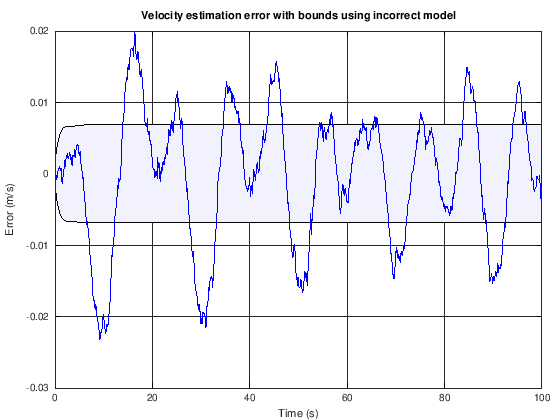

In [5]:
fill([t fliplr(t)],[-boundIMstore(2,:) fliplr(boundIMstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error with bounds using incorrect model'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### (2) Implementing a Kalman filter with incorrect noise variances
The next notebook cell runs a Kalman-filter state estimator that uses incorrect noise variances.

In [6]:
xhat = zeros(nx,1);          % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);       %  and its covariance matrix
xhatBVstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundBVstore = zeros(nx,nt); %  confidence bounds for the bad-variance (BV) case

SigmaWbad = 0.1*SigmaW;
SigmaVbad = 0.1*SigmaV;

for k = 2:nt
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaWbad;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaVbad);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatBVstore(:,k) = xhat; 
  boundBVstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs from Kalman-filter state estimator using incorrect noise variances
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

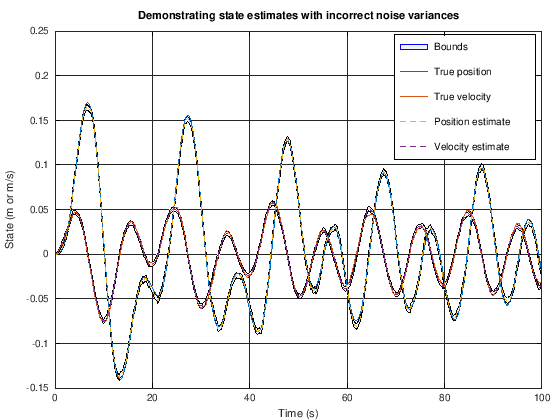

In [7]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatBVstore-boundBVstore fliplr(xhatBVstore+boundBVstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,x',t,xhatBVstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstrating state estimates with incorrect noise variances'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

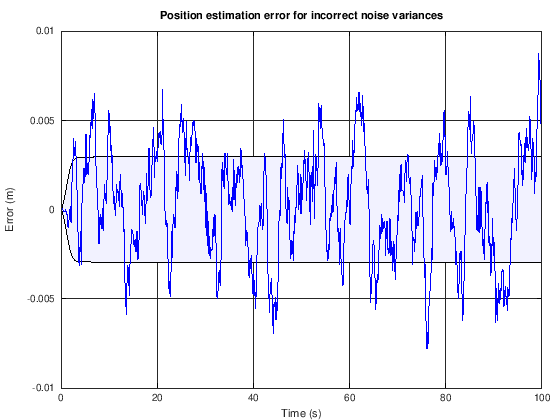

In [8]:
xerr = x - xhatBVstore; 
fill([t fliplr(t)],[-boundBVstore(1,:) fliplr(boundBVstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error for incorrect noise variances'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

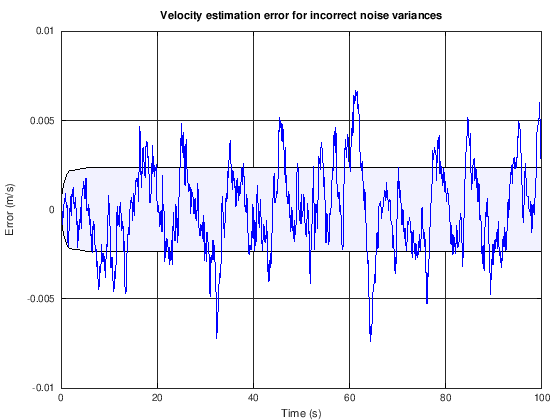

In [9]:
fill([t fliplr(t)],[-boundBVstore(2,:) fliplr(boundBVstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error for incorrect noise variances'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### (3) Implementing a Kalman filter with biased (nonzero-mean) noises
The next notebook cell runs a Kalman-filter state estimator that uses biased noises.

In [10]:
% Data file contains xbias and zbias for simulation using biased noises
load readonly/simOutBiasVars.mat

xhat = zeros(nx,1);          % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);       %  and its covariance matrix
xhatBNstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundBNstore = zeros(nx,nt); %  confidence bounds for the biased-noise (BN) case

for k = 2:nt
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(zbias(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatBNstore(:,k) = xhat; 
  boundBNstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs from Kalman-filter state estimator using biased noises
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

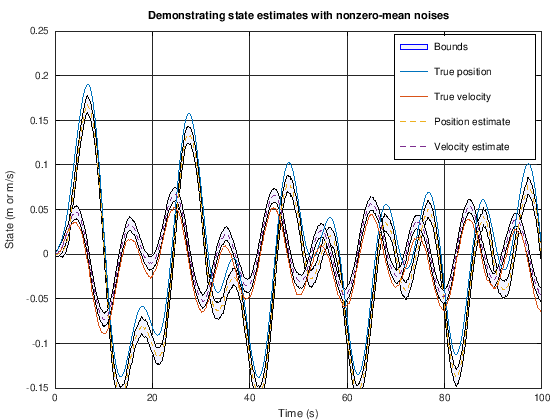

In [11]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatBNstore-boundBNstore fliplr(xhatBNstore+boundBNstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,xbias',t,xhatBNstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstrating state estimates with nonzero-mean noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

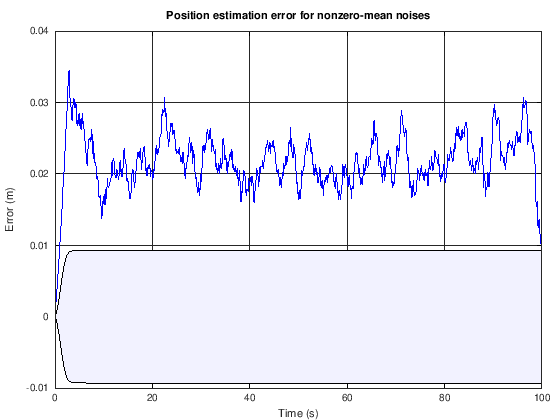

In [12]:
xerr = xbias - xhatBNstore; 
fill([t fliplr(t)],[-boundBNstore(1,:) fliplr(boundBNstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error for nonzero-mean noises'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

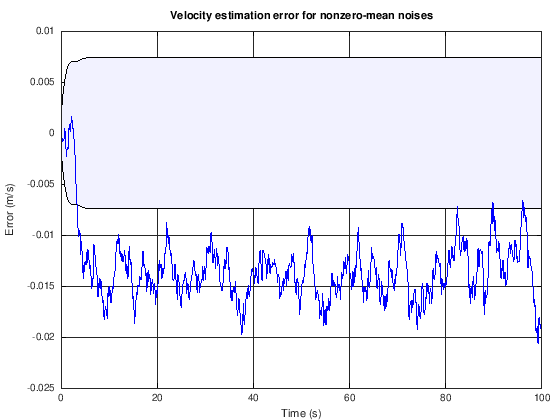

In [13]:
fill([t fliplr(t)],[-boundBNstore(2,:) fliplr(boundBNstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error for nonzero-mean noises'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### (4) Implementing a Kalman filter with correlated noises
The next notebook cell runs a Kalman-filter state estimator that uses correlated noises.

In [14]:
% Data file contains xcorr and zcorr for simulation using biased noises
load readonly/simOutCorrVars.mat

xhat = zeros(nx,1);          % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);       %  and its covariance matrix
xhatCNstore = zeros(nx,nt);  % Reserve storage for all KF state estimates and their
boundCNstore = zeros(nx,nt); %  confidence bounds for the correlated-noise (CN) case

for k = 2:nt
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(zcorr(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatCNstore(:,k) = xhat; 
  boundCNstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs from Kalman-filter state estimator using correlated noises
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

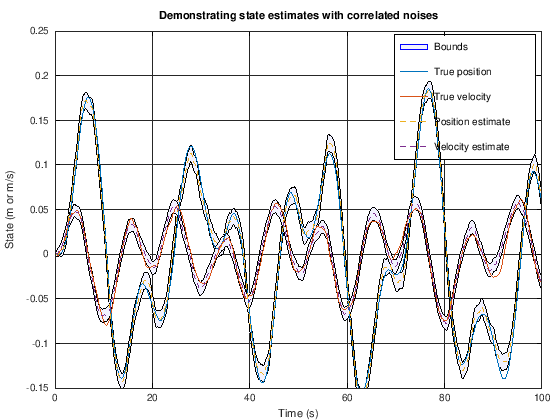

In [15]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatCNstore-boundCNstore fliplr(xhatCNstore+boundCNstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,xcorr',t,xhatCNstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstrating state estimates with correlated noises'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

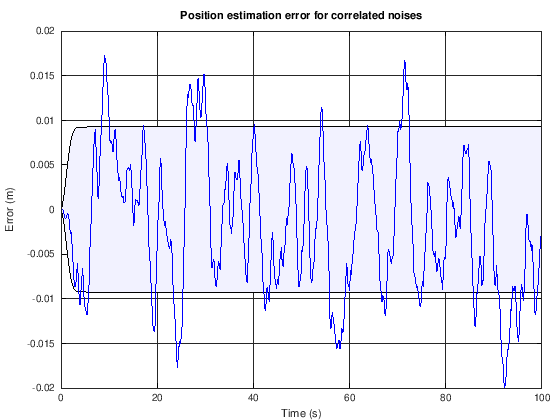

In [16]:
xerr = xcorr - xhatCNstore; 
fill([t fliplr(t)],[-boundCNstore(1,:) fliplr(boundCNstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error for correlated noises'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

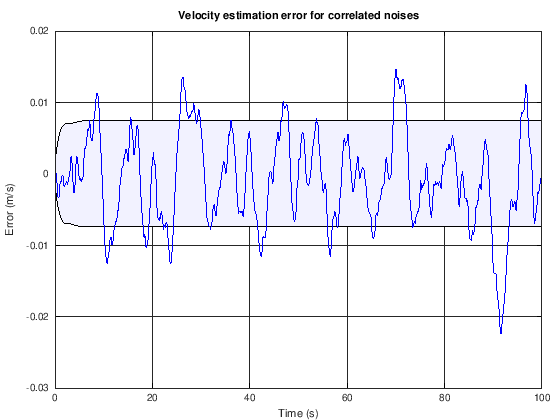

In [17]:
fill([t fliplr(t)],[-boundCNstore(2,:) fliplr(boundCNstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error for correlated noises'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### User workspace
You can enter your own Octave commands into the next cell to query variables, plot results, or anything you like.